# MNIST Digit Classifier Using Deep Learning (TensorFlow/Keras)
- Program: Cyber Shujaa - Data and Artificial Intelligence
- Student Name: Amidu Dabor
- Student ID: CS-DA01-25031
- Date: 21 July 2025

---

## Project Description
This notebook walks through building an Artificial Neural Network (ANN) to classify handwritten digits (0–9) using the MNIST dataset. The model is constructed using TensorFlow and Keras with a focus on modularity, clarity, efficiency, and coding best practices. It includes data preprocessing, model training, evaluation, visualization, and saving/loading for deployment.

---

### Import Libraries

In [9]:
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation Tools
from sklearn.metrics import classification_report, confusion_matrix
from typing import Tuple


In [10]:
# %pip install tensorflow keras seaborn numpy matplotlib scikit-learn

### Define MNISTClassifier Class (OOP Design)

In [39]:
class MNISTClassifier:
    """
    A Deep Learning classifier for handwritten digit recognition using Keras and the MNIST dataset.
    """
    
    def __init__(self):
        self.model = None
        self.history = None

    def load_and_preprocess_data(self) -> Tuple[Tuple[np.ndarray, np.ndarray], Tuple[np.ndarray, np.ndarray]]:
        (X_train, y_train), (X_test, y_test) = mnist.load_data()
        X_train, X_test = X_train / 255.0, X_test / 255.0
        y_train_cat = to_categorical(y_train, 10)
        y_test_cat = to_categorical(y_test, 10)

        return (X_train, y_train, y_train_cat), (X_test, y_test, y_test_cat)

    def visualize_samples(self, X: np.ndarray, y: np.ndarray, indices: list):
        plt.figure(figsize=(8, 8))
        for i, idx in enumerate(indices):
            plt.subplot(3, 3, i + 1)
            plt.imshow(X[idx], cmap='gray')
            plt.title(f"Label: {y[idx]} (Idx: {idx})")
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    def build_model(self, input_shape: Tuple[int, int] = (28, 28)) -> None:
        self.model = Sequential([
            Flatten(input_shape=input_shape),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(10, activation='softmax')
        ])
        self.model.summary()

    def compile_model(self) -> None:
        self.model.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])
        
    def train_without_early_stopping(self, X_train: np.ndarray, y_train: np.ndarray, epochs: int = 10, batch_size: int = 128):
        """
        Trains the model and stores the history.
        """
        self.history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=2
            )

    def train_with_early_stopping(self, X_train: np.ndarray, y_train: np.ndarray, epochs: int = 10, batch_size: int = 128):
        """
        Trains the model using early stopping and stores the history.
        """
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True,
        )

        self.history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            callbacks=[early_stop]
        )

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray) -> float:
        loss, acc = self.model.evaluate(X_test, y_test)
        print(f"\nTest Accuracy: {acc:.4f}")
        return acc

    def plot_history(self) -> None:
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(self.history.history['accuracy'], label='Train')
        plt.plot(self.history.history['val_accuracy'], label='Validation')
        plt.title("Model Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.history.history['loss'], label='Train Loss')
        plt.plot(self.history.history['val_loss'], label='Val Loss')
        plt.title("Model Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def report_results(self, X_test: np.ndarray, y_test: np.ndarray, y_true: np.ndarray):
        y_pred = np.argmax(self.model.predict(X_test), axis=1)
        print("\nClassification Report:\n")
        print(classification_report(y_true, y_pred))

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    def save_model(self, filename: str = "mnist_ann_model.keras") -> None:
        self.model.save(filename)
        print(f"\nModel saved to {filename}")

    def load_model(self, filename: str = "mnist_ann_model.keras") -> None:
        self.model = load_model(filename)
        print(f"\nModel loaded from {filename}")


### Execution Pipeline

#### 1. Instantiate and run the classifier

In [40]:
# Instantiate and run the classifier
classifier = MNISTClassifier()

#### 2. Load and preprocess data

In [41]:
# Load and preprocess data
(train_X, train_y, train_y_cat), (test_X, test_y, test_y_cat) = classifier.load_and_preprocess_data()

print("Shape of x_train:", (train_X, train_y, train_y_cat)[0].shape, "| Shape of y_train:", (train_X, train_y, train_y_cat)[2].shape)
print("Shape of x_test:", (test_X, test_y, test_y_cat)[0].shape, "| Shape of y_test:", (test_X, test_y, test_y_cat)[2].shape)

Shape of x_train: (60000, 28, 28) | Shape of y_train: (60000, 10)
Shape of x_test: (10000, 28, 28) | Shape of y_test: (10000, 10)


#### 3. Visualize sample digits

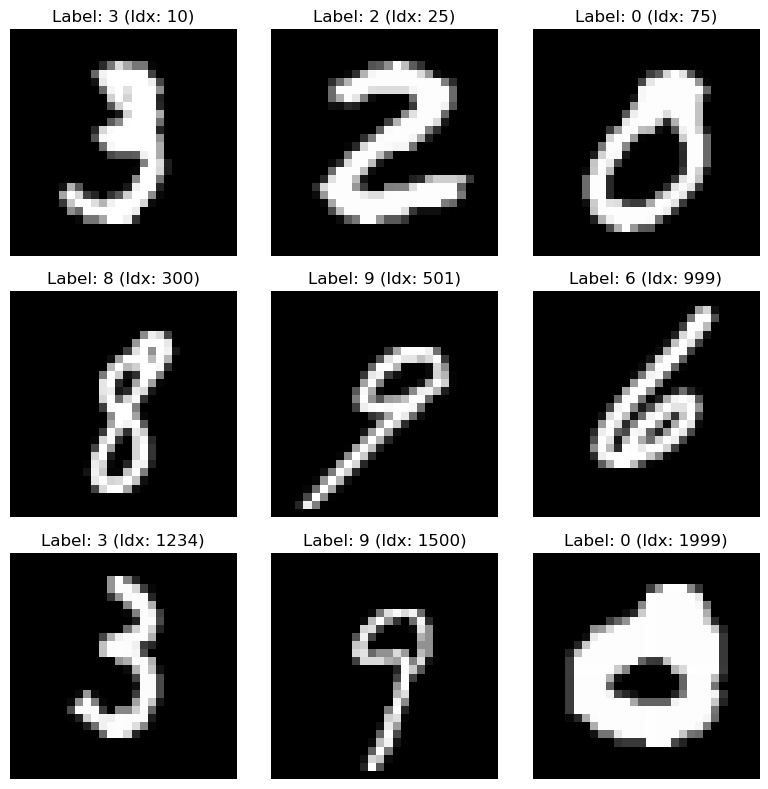

In [42]:
# Visualize sample digits
classifier.visualize_samples(train_X, train_y, [10, 25, 75, 300, 501, 999, 1234, 1500, 1999])

#### 4. Build and compile the ANN model

In [43]:
# Build model
classifier.build_model()
# Compile model
classifier.compile_model()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#### 5. Train model (without early stopping implemented)

In [38]:
# Train model - early stopping not applied
classifier.train_without_early_stopping(train_X, train_y_cat)

Epoch 1/10
422/422 - 1s - 3ms/step - accuracy: 0.8316 - loss: 0.5506 - val_accuracy: 0.9550 - val_loss: 0.1581
Epoch 2/10
422/422 - 1s - 2ms/step - accuracy: 0.9285 - loss: 0.2471 - val_accuracy: 0.9667 - val_loss: 0.1166
Epoch 3/10
422/422 - 1s - 2ms/step - accuracy: 0.9444 - loss: 0.1935 - val_accuracy: 0.9718 - val_loss: 0.0958
Epoch 4/10
422/422 - 1s - 2ms/step - accuracy: 0.9527 - loss: 0.1634 - val_accuracy: 0.9748 - val_loss: 0.0846
Epoch 5/10
422/422 - 1s - 2ms/step - accuracy: 0.9585 - loss: 0.1427 - val_accuracy: 0.9762 - val_loss: 0.0831
Epoch 6/10
422/422 - 1s - 2ms/step - accuracy: 0.9616 - loss: 0.1285 - val_accuracy: 0.9763 - val_loss: 0.0788
Epoch 7/10
422/422 - 1s - 2ms/step - accuracy: 0.9654 - loss: 0.1170 - val_accuracy: 0.9780 - val_loss: 0.0719
Epoch 8/10
422/422 - 1s - 2ms/step - accuracy: 0.9681 - loss: 0.1065 - val_accuracy: 0.9788 - val_loss: 0.0725
Epoch 9/10
422/422 - 1s - 2ms/step - accuracy: 0.9696 - loss: 0.1016 - val_accuracy: 0.9787 - val_loss: 0.0726
E

#### 6. Train model (with early stopping implemented)

In [44]:
# Train model - early stopping applied
classifier.train_with_early_stopping(train_X, train_y_cat)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7088 - loss: 0.9001 - val_accuracy: 0.9552 - val_loss: 0.1597
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9232 - loss: 0.2646 - val_accuracy: 0.9672 - val_loss: 0.1133
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9409 - loss: 0.2009 - val_accuracy: 0.9747 - val_loss: 0.0940
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9517 - loss: 0.1652 - val_accuracy: 0.9762 - val_loss: 0.0827
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9580 - loss: 0.1423 - val_accuracy: 0.9763 - val_loss: 0.0791
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9608 - loss: 0.1277 - val_accuracy: 0.9797 - val_loss: 0.0744
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9654 - loss: 0.1140 - val_accuracy: 0.9783 - val_loss: 0.0725
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9671 - loss: 0.1058 - val_accuracy: 0.

#### 7. Evaluate performance

In [45]:
# Evaluate model performance
classifier.evaluate(test_X, test_y_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.9746 - loss: 0.0873

Test Accuracy: 0.9779


0.9779000282287598

#### 8. Training history

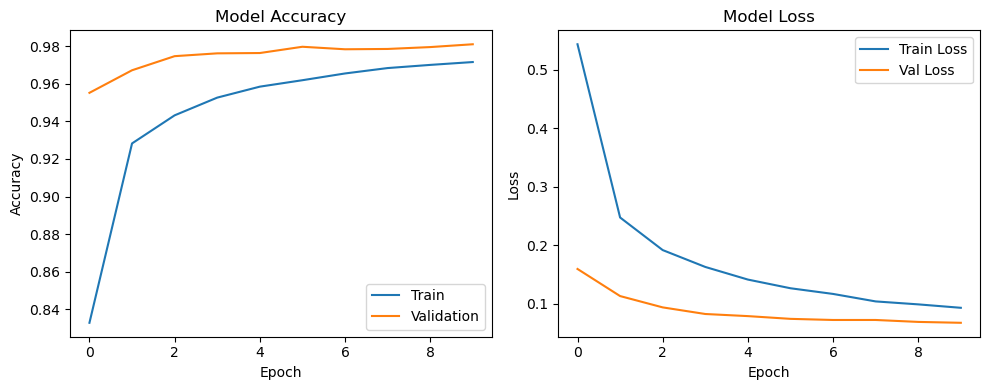

In [46]:
# Training plots
classifier.plot_history()

#### 9. Report results - Classification report & Confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



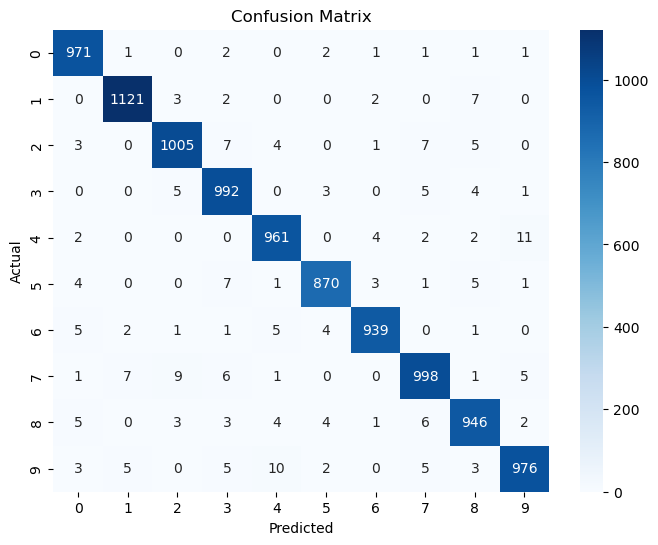

In [47]:
# Report
classifier.report_results(test_X, test_y_cat, test_y)

#### 10. Save model

In [48]:
# Save model
classifier.save_model()


Model saved to mnist_ann_model.keras


#### 11. Load and re-evaluate performance

In [49]:
# Load model
classifier.load_model()
# Re-evaluate performance
classifier.evaluate(test_X, test_y_cat)


Model loaded from mnist_ann_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - accuracy: 0.9746 - loss: 0.0873

Test Accuracy: 0.9779


0.9779000282287598